# estimating probability of kind-linked

In [3]:
import gp
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

## import zarpie features
each row is a feature. columns: category (personality, physical, diet), split (train or test), in_heterogenous (whether or not it was used for train / test in heterogenous condition), 2d embedding, 384d embedding.

In [5]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

In [6]:
df.head()

,feature,category,split,in_heterogenous,x_2d,y_2d,embedding_384d
0,are angry,personality_behaviors,train,True,-0.073863,-0.238874,"[-0.02164809, 0.050021496, -0.027437702, 0.012..."
1,are brave,personality_behaviors,train,True,-0.100276,-0.269504,"[-0.022016477, -0.029494364, -0.042321444, 0.0..."
2,are curious,personality_behaviors,train,False,-0.085597,-0.184920,"[-0.06632441, 0.060695983, 0.0322907, 0.080090..."
3,are forgetful,personality_behaviors,train,False,-0.047072,-0.263889,"[-0.047100894, -0.008117868, -0.013956301, 0.0..."
4,are friendly,personality_behaviors,train,True,0.030569,-0.241963,"[-0.03688672, 0.047983356, -0.044930663, 0.021..."


In [7]:
phys_df = df[df['category'] == 'physical']
phys_df

,feature,category,split,in_heterogenous,x_2d,y_2d,embedding_384d
10,can roll their tongue,physical,test,False,-0.059797,0.049082,"[-0.04557631, 0.050970126, -0.024809176, -0.00..."
11,can see really far,physical,train,False,-0.149212,-0.076074,"[-0.009260512, 0.046762295, -0.07884355, 0.050..."
12,can snap with their toes,physical,test,False,-0.337391,0.194453,"[-0.051987637, 0.079508185, -0.015802959, 0.00..."
13,can touch their toes,physical,train,True,-0.334749,0.183512,"[-0.072572455, 0.071725756, -0.03638175, 0.001..."
14,can wiggle their ears,physical,test,False,-0.264249,0.042144,"[-0.033690855, 0.00076530117, -0.060950723, 0...."
16,draw circles on their knees,physical,train,False,-0.352429,0.129593,"[0.00054139935, 0.0146051245, -0.035719063, -0..."
26,have a flat belly button,physical,train,True,-0.193772,0.176596,"[-0.002618113, -0.027462484, -0.082157716, 0.0..."
27,have a loud voice,physical,train,False,-0.058055,-0.139414,"[-0.004545202, 0.013106136, -0.043702494, 0.08..."
28,have bony elbows,physical,train,False,-0.295247,0.285881,"[-0.015668994, 0.035148133, -0.067058556, 0.03..."
29,have cold hands and feet,physical,test,False,-0.293175,0.185171,"[-0.01657701, -0.0030899595, -0.14596134, -0.0..."


In [8]:
# 2d gp where the train features are 1 (kind-linked) and the test features are unknown / need to be predicted
# then other features possibly in the space should also be predicted

# Reload gp module to pick up changes
import importlib
importlib.reload(gp)

<module 'gp' from '/Users/mayamalaviya/Documents/PhD/GP Generics/compgenerics/model/gp/gp.py'>

In [9]:
# Extract training data (physical features in train split - these are kind-linked)
train_df = phys_df[phys_df['split'] == 'train']
train_coords = jnp.array(train_df[['x_2d', 'y_2d']].values)
train_labels = jnp.ones(len(train_coords))  # All training features are kind-linked (y=1)

# Extract test data (need to predict P(kind-linked))
test_df = phys_df[phys_df['split'] == 'test']
test_coords = jnp.array(test_df[['x_2d', 'y_2d']].values)

print(f"Training: {len(train_coords)} points")
print(f"Test: {len(test_coords)} points")

Training: 15 points
Test: 5 points


In [10]:
# Run Bernoulli GP classification
# prior_mean=-2.0 means P(kind-linked) ≈ 0.12 far from training data
results = gp.bernoulli_gp_classify(
    train_coords=train_coords,
    train_labels=train_labels,
    test_coords=test_coords,
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0,
    return_latent=True
)

# Show results
print("Predicted P(kind-linked) for test features:")
print("-" * 50)
for feat, prob in zip(test_df['feature'].values, results['probabilities']):
    print(f"  {feat}: {float(prob):.3f}")

Predicted P(kind-linked) for test features:
--------------------------------------------------
  can roll their tongue: 0.637
  can snap with their toes: 0.677
  can wiggle their ears: 0.708
  have cold hands and feet: 0.697
  snore when they sleep: 0.567


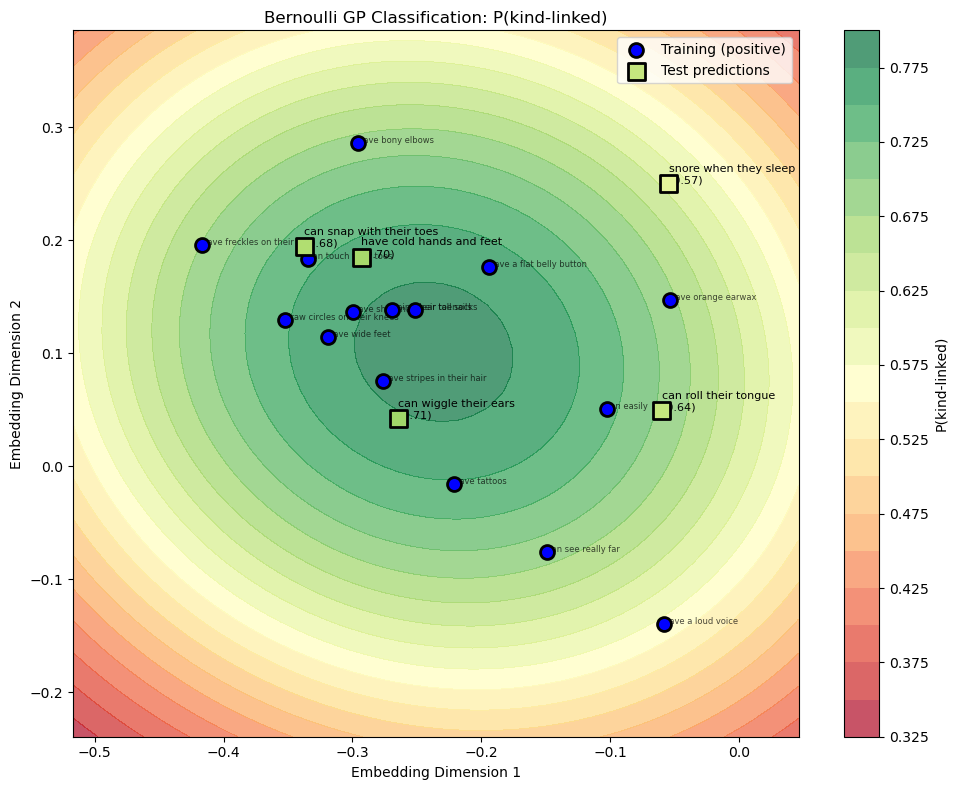

In [11]:
# Visualize the GP classification
gp.visualize_bernoulli_gp(
    train_coords=train_coords,
    train_labels=train_labels,
    test_coords=test_coords,
    predictions=results,
    feature_names_train=list(train_df['feature'].values),
    feature_names_test=list(test_df['feature'].values),
    grid_resolution=50,
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0
)
plt.show()

In [12]:
# Show best hyperparameters found
print("Best hyperparameters (by marginal likelihood):")
spec = gp.get_kernel("rbf_2d_ard")
for name, val in zip(spec.param_names, results['best_params']):
    print(f"  {name}: {float(val):.4f}")

Best hyperparameters (by marginal likelihood):
  sigma: 1.0000
  lengthscale_x: 0.3000
  lengthscale_y: 0.3000


## Predict on all features (not just physical)

We can also predict P(kind-linked) for features from other categories to see how the model generalizes.

In [13]:
# Predict on ALL features in the dataframe
all_coords = jnp.array(df[['x_2d', 'y_2d']].values)

# Get predictions for all features
all_probs, all_f_mean, all_f_var = gp.laplace_predict(
    X_train=train_coords,
    y_train=train_labels,
    X_test=all_coords,
    kernel_params=results['best_params'],
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0
)

In [14]:
# Add predictions to dataframe for analysis
df_with_preds = df.copy()
df_with_preds['p_kind_linked'] = np.array(all_probs)
df_with_preds['latent_mean'] = np.array(all_f_mean)
df_with_preds['latent_var'] = np.array(all_f_var)

# Show predictions by category
for cat in df['category'].unique():
    print(f"\n{cat.upper()}:")
    cat_df = df_with_preds[df_with_preds['category'] == cat].sort_values('p_kind_linked', ascending=False)
    for _, row in cat_df.iterrows():
        marker = "✓" if row['split'] == 'train' else "?"
        print(f"  {marker} {row['feature']}: {row['p_kind_linked']:.3f}")


PERSONALITY_BEHAVIORS:
  ✓ can do cartwheels: 0.758
  ? like to dance: 0.605
  ✓ live with their families: 0.598
  ? cry easily: 0.588
  ✓ like to ride bikes: 0.551
  ✓ are curious: 0.533
  ✓ tell bad jokes: 0.527
  ✓ teach children: 0.495
  ✓ are silly: 0.485
  ✓ are angry: 0.461
  ✓ are brave: 0.435
  ✓ take care of others: 0.426
  ✓ are smart: 0.426
  ✓ are forgetful: 0.419
  ? like to give high-fives: 0.398
  ✓ are friendly: 0.395
  ? like to read books: 0.390
  ? like to collect rocks: 0.364
  ✓ give good gifts: 0.360
  ✓ are thoughtful: 0.292

DIET_PREFERENCES:
  ✓ farm potatoes: 0.399
  ✓ make bread: 0.364
  ✓ really don't like ice cream: 0.358
  ✓ eat cheese: 0.341
  ✓ eat nuts: 0.334
  ✓ like to eat sweets: 0.318
  ✓ like to drink fizzy water: 0.302
  ✓ really don't like soup: 0.300
  ✓ drink milk: 0.295
  ? like juice with pulp: 0.291
  ? eat breakfast very late: 0.285
  ✓ eat meat: 0.285
  ✓ like to eat herbs: 0.280
  ✓ like to drink tea: 0.278
  ? can eat spicy food: 0.260

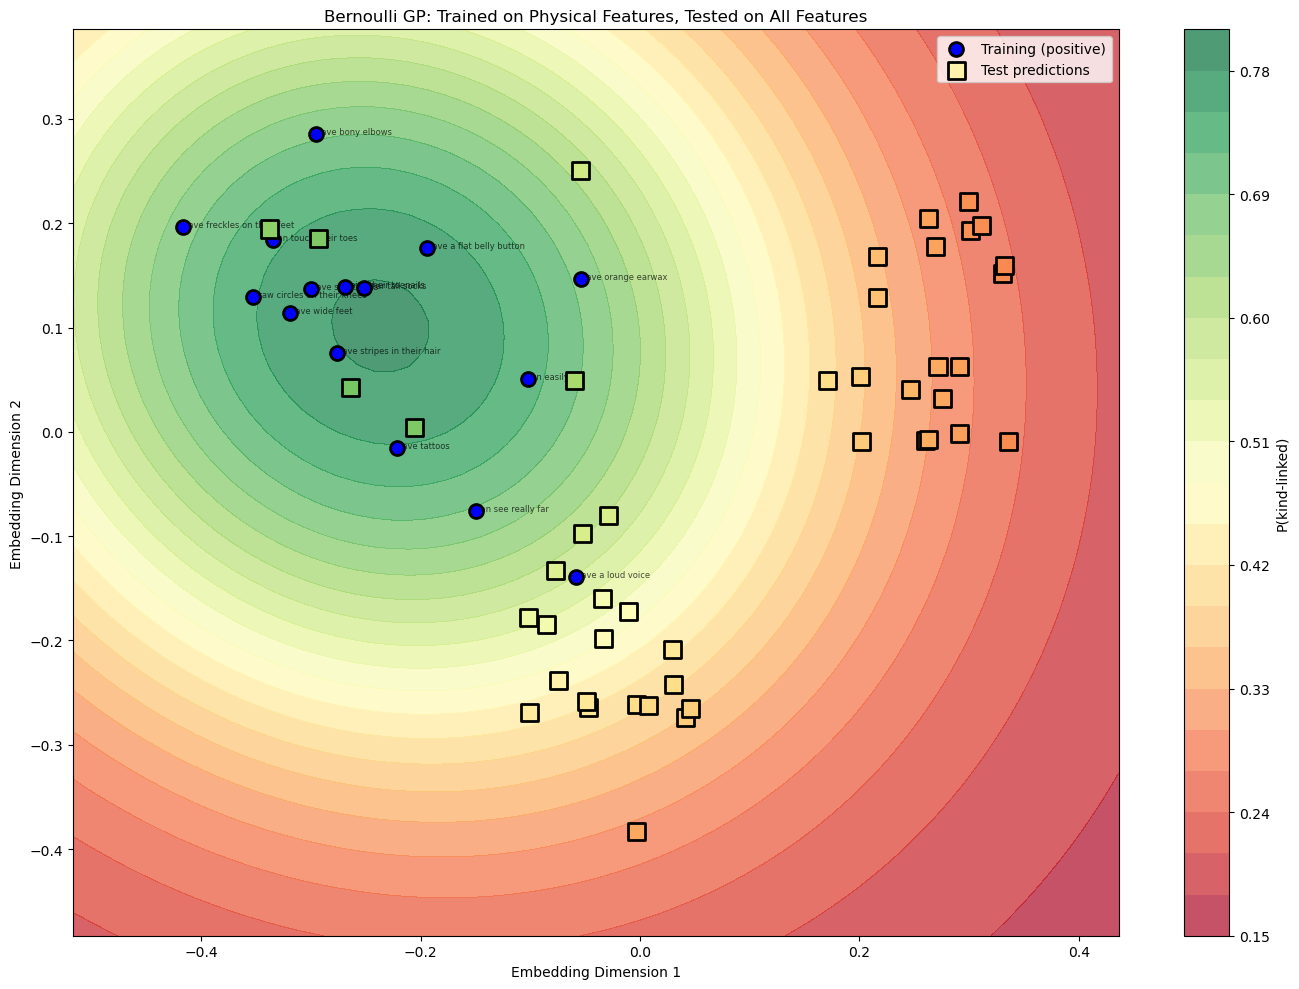

In [15]:
# Visualize: trained on physical features, tested on ALL features
# Create a results dict for all features
all_results = {
    'probabilities': all_probs,
    'best_params': results['best_params'],
}

# Get all non-training features as "test" for visualization
non_train_mask = ~((df['category'] == 'physical') & (df['split'] == 'train'))
all_test_coords = jnp.array(df[non_train_mask][['x_2d', 'y_2d']].values)
all_test_names = list(df[non_train_mask]['feature'].values)

# Get predictions just for non-training features
all_test_probs, _, _ = gp.laplace_predict(
    X_train=train_coords,
    y_train=train_labels,
    X_test=all_test_coords,
    kernel_params=results['best_params'],
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0
)

all_test_results = {
    'probabilities': all_test_probs,
    'best_params': results['best_params'],
}

# Visualize with all features
fig, ax = plt.subplots(figsize=(14, 10))
gp.visualize_bernoulli_gp(
    train_coords=train_coords,
    train_labels=train_labels,
    test_coords=all_test_coords,
    predictions=all_test_results,
    feature_names_train=list(train_df['feature'].values),
    feature_names_test=None,  # Too many to label
    grid_resolution=60,
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0,
    ax=ax
)
ax.set_title('Bernoulli GP: Trained on Physical Features, Tested on All Features')
plt.tight_layout()
plt.show()

Heterogenous training features: 15
['are angry', 'are brave', 'are friendly', 'can touch their toes', 'eat rice', 'have a flat belly button', 'have freckles on their feet', 'have orange earwax', 'like to eat broccoli', 'like to eat herbs', 'like to ride bikes', 'make bread', "really don't like soup", 'tan easily', 'tell bad jokes']


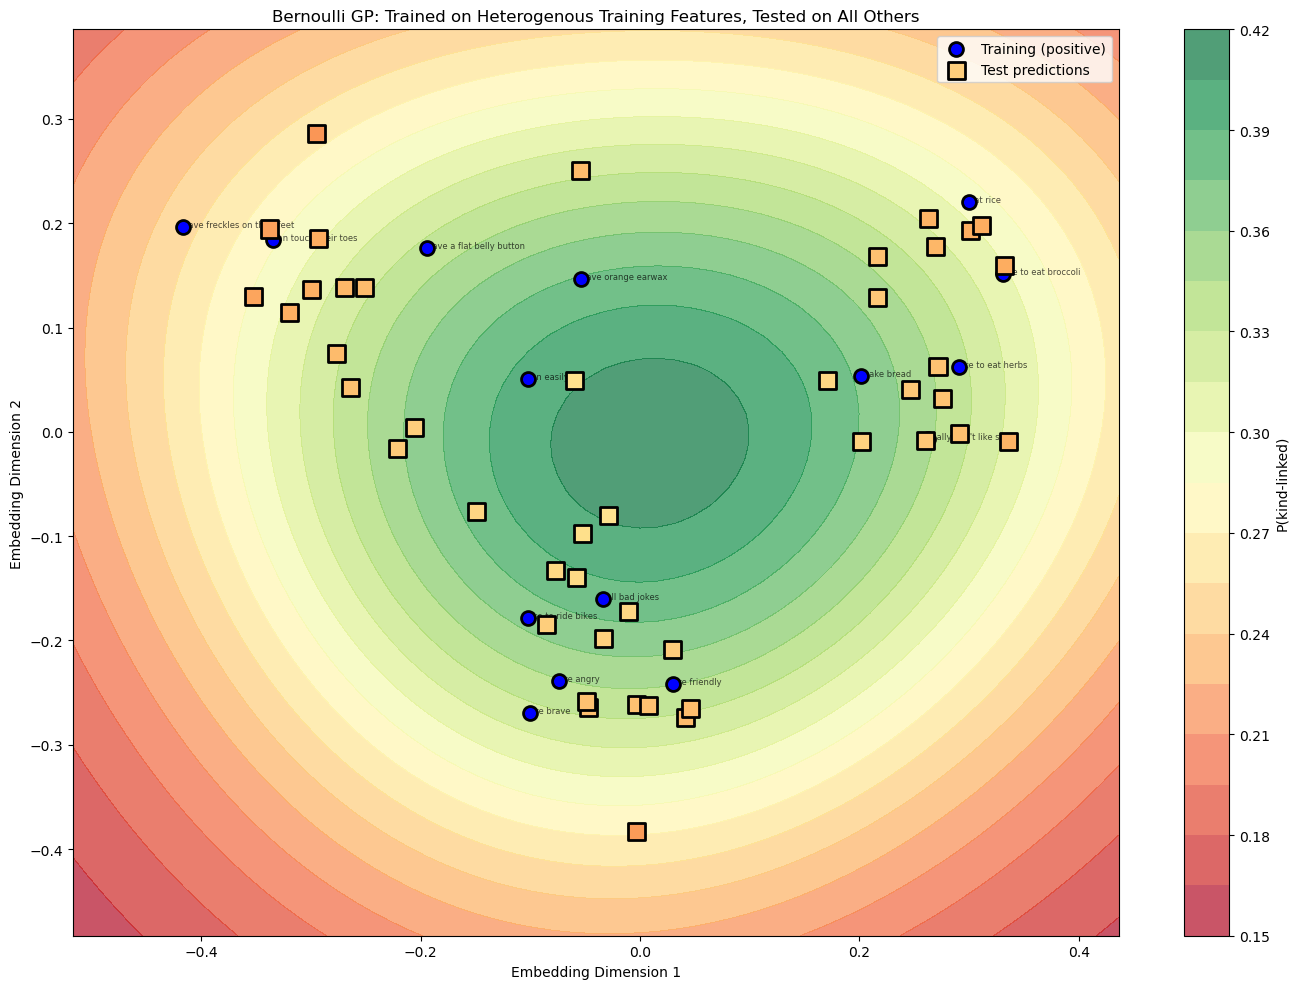

In [16]:
# Train on heterogenous training features only, test on all others
hetero_train_df = df[(df['in_heterogenous'] == True) & (df['split'] == 'train')]
hetero_train_coords = jnp.array(hetero_train_df[['x_2d', 'y_2d']].values)
hetero_train_labels = jnp.ones(len(hetero_train_coords))

print(f"Heterogenous training features: {len(hetero_train_coords)}")
print(hetero_train_df['feature'].tolist())

# Run classification
hetero_results = gp.bernoulli_gp_classify(
    train_coords=hetero_train_coords,
    train_labels=hetero_train_labels,
    test_coords=jnp.array(df[['x_2d', 'y_2d']].values),  # dummy, we'll predict separately
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0,
    return_latent=False
)

# Get all non-heterogenous-training features as "test"
non_hetero_train_mask = ~((df['in_heterogenous'] == True) & (df['split'] == 'train'))
hetero_test_coords = jnp.array(df[non_hetero_train_mask][['x_2d', 'y_2d']].values)
hetero_test_names = list(df[non_hetero_train_mask]['feature'].values)

# Get predictions for test features
hetero_test_probs, _, _ = gp.laplace_predict(
    X_train=hetero_train_coords,
    y_train=hetero_train_labels,
    X_test=hetero_test_coords,
    kernel_params=hetero_results['best_params'],
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0
)

hetero_test_results = {
    'probabilities': hetero_test_probs,
    'best_params': hetero_results['best_params'],
}

# Visualize
fig, ax = plt.subplots(figsize=(14, 10))
gp.visualize_bernoulli_gp(
    train_coords=hetero_train_coords,
    train_labels=hetero_train_labels,
    test_coords=hetero_test_coords,
    predictions=hetero_test_results,
    feature_names_train=list(hetero_train_df['feature'].values),
    feature_names_test=None,
    grid_resolution=60,
    kernel_name="rbf_2d_ard",
    prior_mean=-2.0,
    ax=ax
)
ax.set_title('Bernoulli GP: Trained on Heterogenous Training Features, Tested on All Others')
# plt.tight_layout()
plt.show()

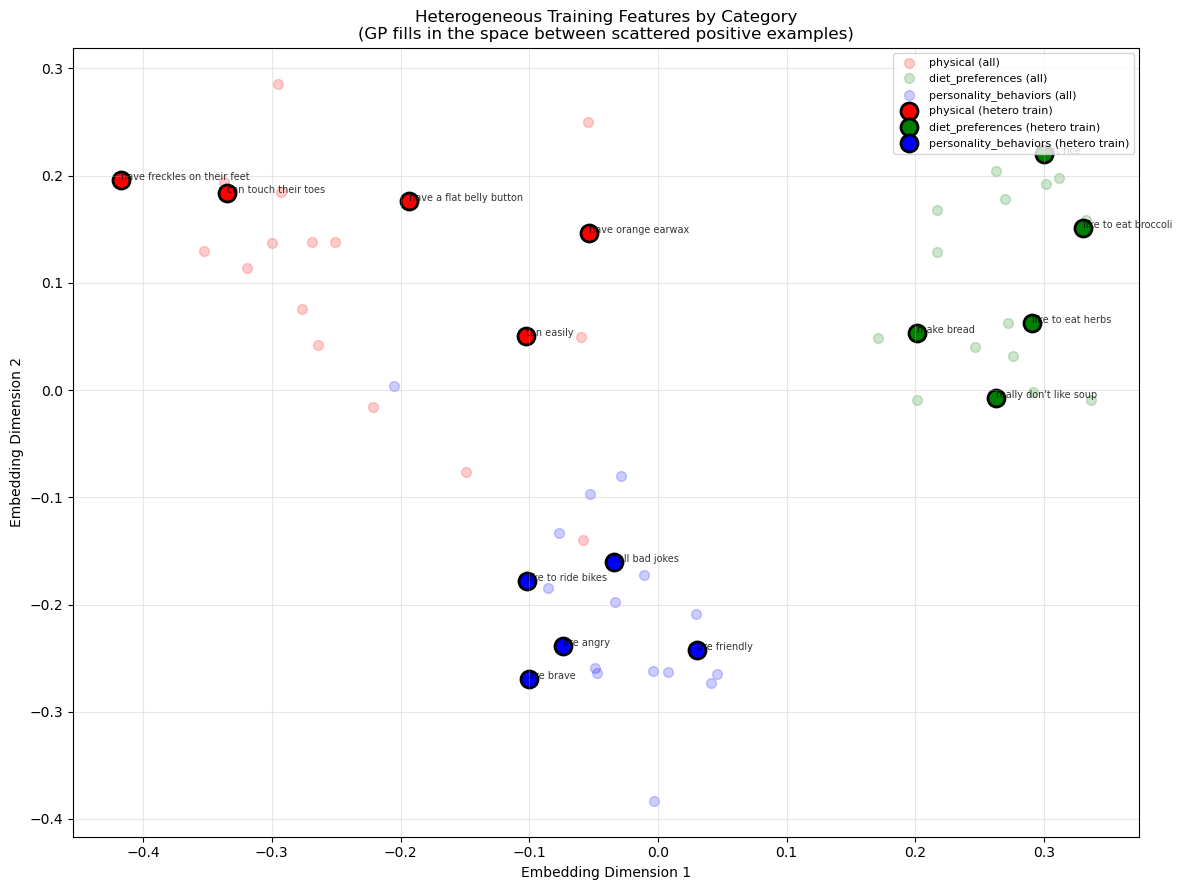


Heterogeneous training features by category:

physical: 5 features
  - can touch their toes
  - have a flat belly button
  - have freckles on their feet
  - have orange earwax
  - tan easily

diet_preferences: 5 features
  - eat rice
  - like to eat broccoli
  - like to eat herbs
  - make bread
  - really don't like soup

personality_behaviors: 5 features
  - are angry
  - are brave
  - are friendly
  - like to ride bikes
  - tell bad jokes


In [17]:
# Visualize WHERE the heterogeneous training points are by category
# This explains why there's a high-probability region in the middle

fig, ax = plt.subplots(figsize=(12, 9))

# Plot ALL features by category (faded)
colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}
for cat, color in colors.items():
    cat_df = df[df['category'] == cat]
    ax.scatter(cat_df['x_2d'], cat_df['y_2d'], 
               c=color, alpha=0.2, s=50, label=f'{cat} (all)')

# Highlight heterogeneous training features
hetero_train = df[(df['in_heterogenous'] == True) & (df['split'] == 'train')]
for cat, color in colors.items():
    cat_hetero = hetero_train[hetero_train['category'] == cat]
    ax.scatter(cat_hetero['x_2d'], cat_hetero['y_2d'], 
               c=color, s=150, edgecolors='black', linewidths=2,
               label=f'{cat} (hetero train)', marker='o')
    # Label them
    for _, row in cat_hetero.iterrows():
        ax.annotate(row['feature'], (row['x_2d'], row['y_2d']), 
                   fontsize=7, alpha=0.8)

ax.set_xlabel('Embedding Dimension 1')
ax.set_ylabel('Embedding Dimension 2')
ax.set_title('Heterogeneous Training Features by Category\n(GP fills in the space between scattered positive examples)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHeterogeneous training features by category:")
for cat in colors.keys():
    cat_hetero = hetero_train[hetero_train['category'] == cat]
    print(f"\n{cat}: {len(cat_hetero)} features")
    for _, row in cat_hetero.iterrows():
        print(f"  - {row['feature']}")

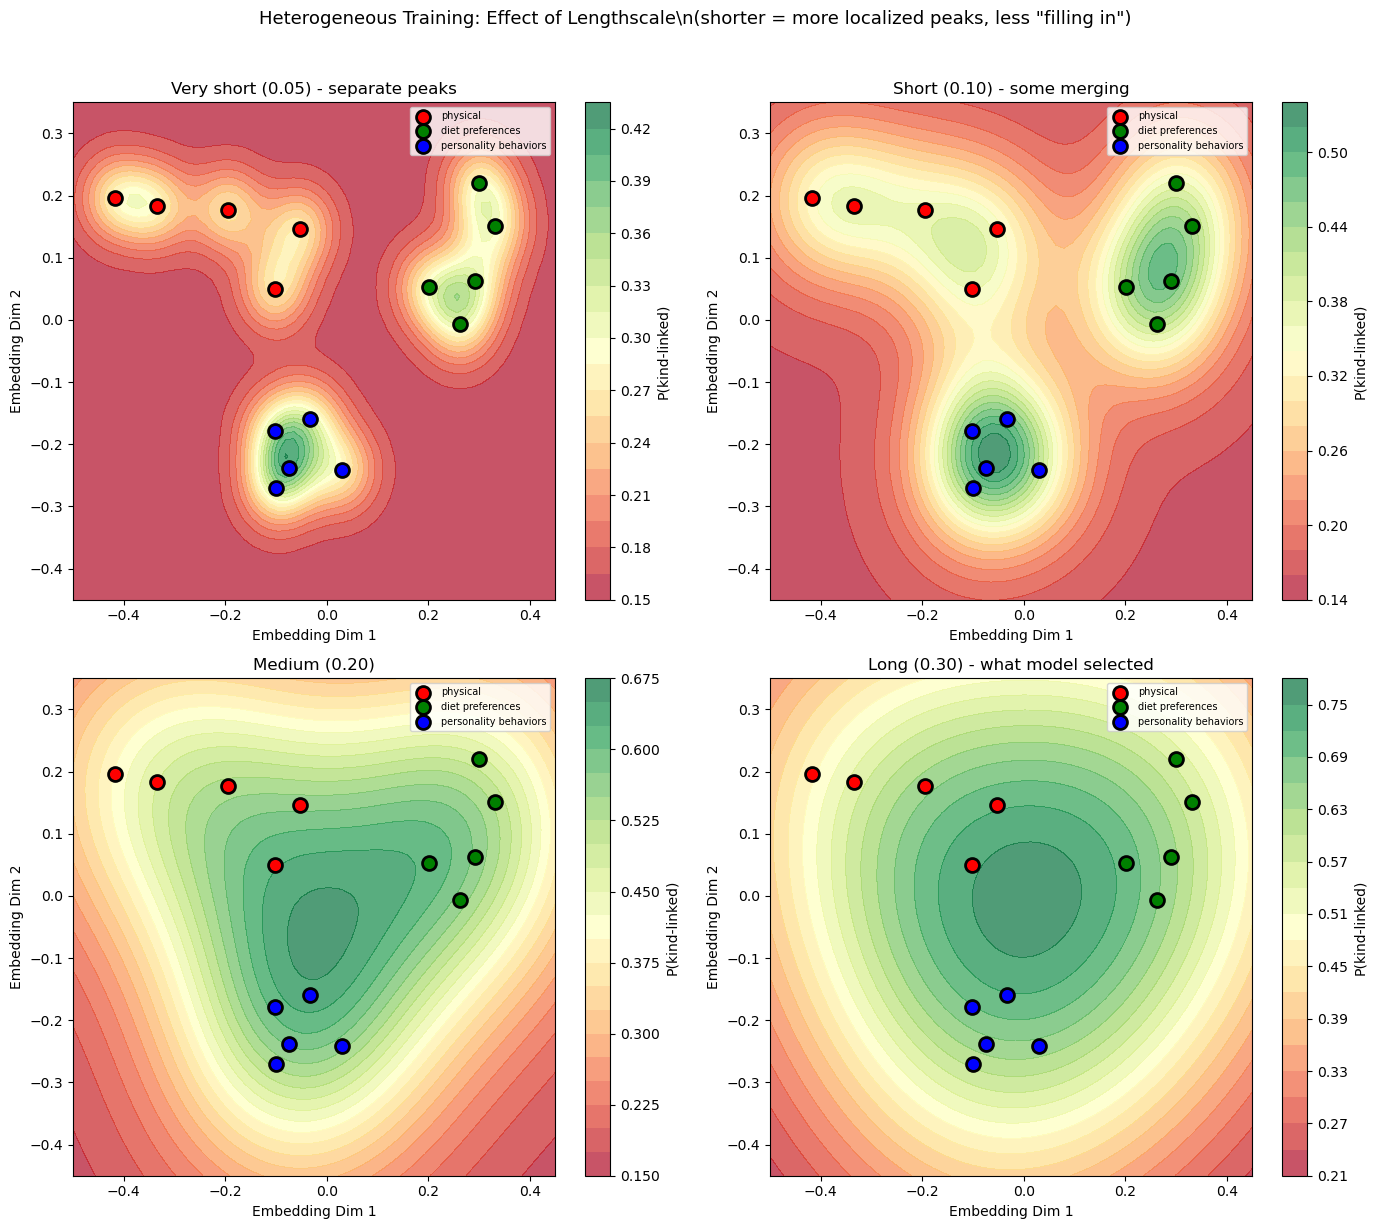

In [18]:
# Compare lengthscales for the HETEROGENEOUS training case
# Shorter lengthscales = more localized peaks around each training point

lengthscale_settings = [
    (0.05, 0.05, "Very short (0.05) - separate peaks"),
    (0.10, 0.10, "Short (0.10) - some merging"),
    (0.20, 0.20, "Medium (0.20)"),
    (0.30, 0.30, "Long (0.30) - what model selected"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Color markers by category
cat_colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}

for ax, (lx, ly, title) in zip(axes, lengthscale_settings):
    manual_params = jnp.array([1.0, lx, ly])
    
    # Create grid
    x_min, x_max = -0.5, 0.45
    y_min, y_max = -0.45, 0.35
    xx, yy = jnp.meshgrid(
        jnp.linspace(x_min, x_max, 60),
        jnp.linspace(y_min, y_max, 60)
    )
    grid_coords = jnp.stack([xx.ravel(), yy.ravel()], axis=1)
    
    # Predict using heterogeneous training data
    probs_grid, _, _ = gp.laplace_predict(
        X_train=hetero_train_coords,
        y_train=hetero_train_labels,
        X_test=grid_coords,
        kernel_params=manual_params,
        kernel_name="rbf_2d_ard",
        prior_mean=-2.0
    )
    probs_grid = probs_grid.reshape(xx.shape)
    
    # Plot heatmap
    im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='RdYlGn', alpha=0.7)
    plt.colorbar(im, ax=ax, label='P(kind-linked)')
    
    # Plot heterogeneous training points colored by category
    for cat, color in cat_colors.items():
        cat_mask = hetero_train_df['category'] == cat
        cat_coords = hetero_train_coords[cat_mask.values]
        ax.scatter(cat_coords[:, 0], cat_coords[:, 1], 
                   c=color, s=100, edgecolors='black', linewidths=2,
                   label=cat.replace('_', ' '), zorder=5)
    
    ax.set_xlabel('Embedding Dim 1')
    ax.set_ylabel('Embedding Dim 2')
    ax.set_title(f'{title}')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='upper right', fontsize=7)

plt.suptitle('Heterogeneous Training: Effect of Lengthscale\\n(shorter = more localized peaks, less "filling in")', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

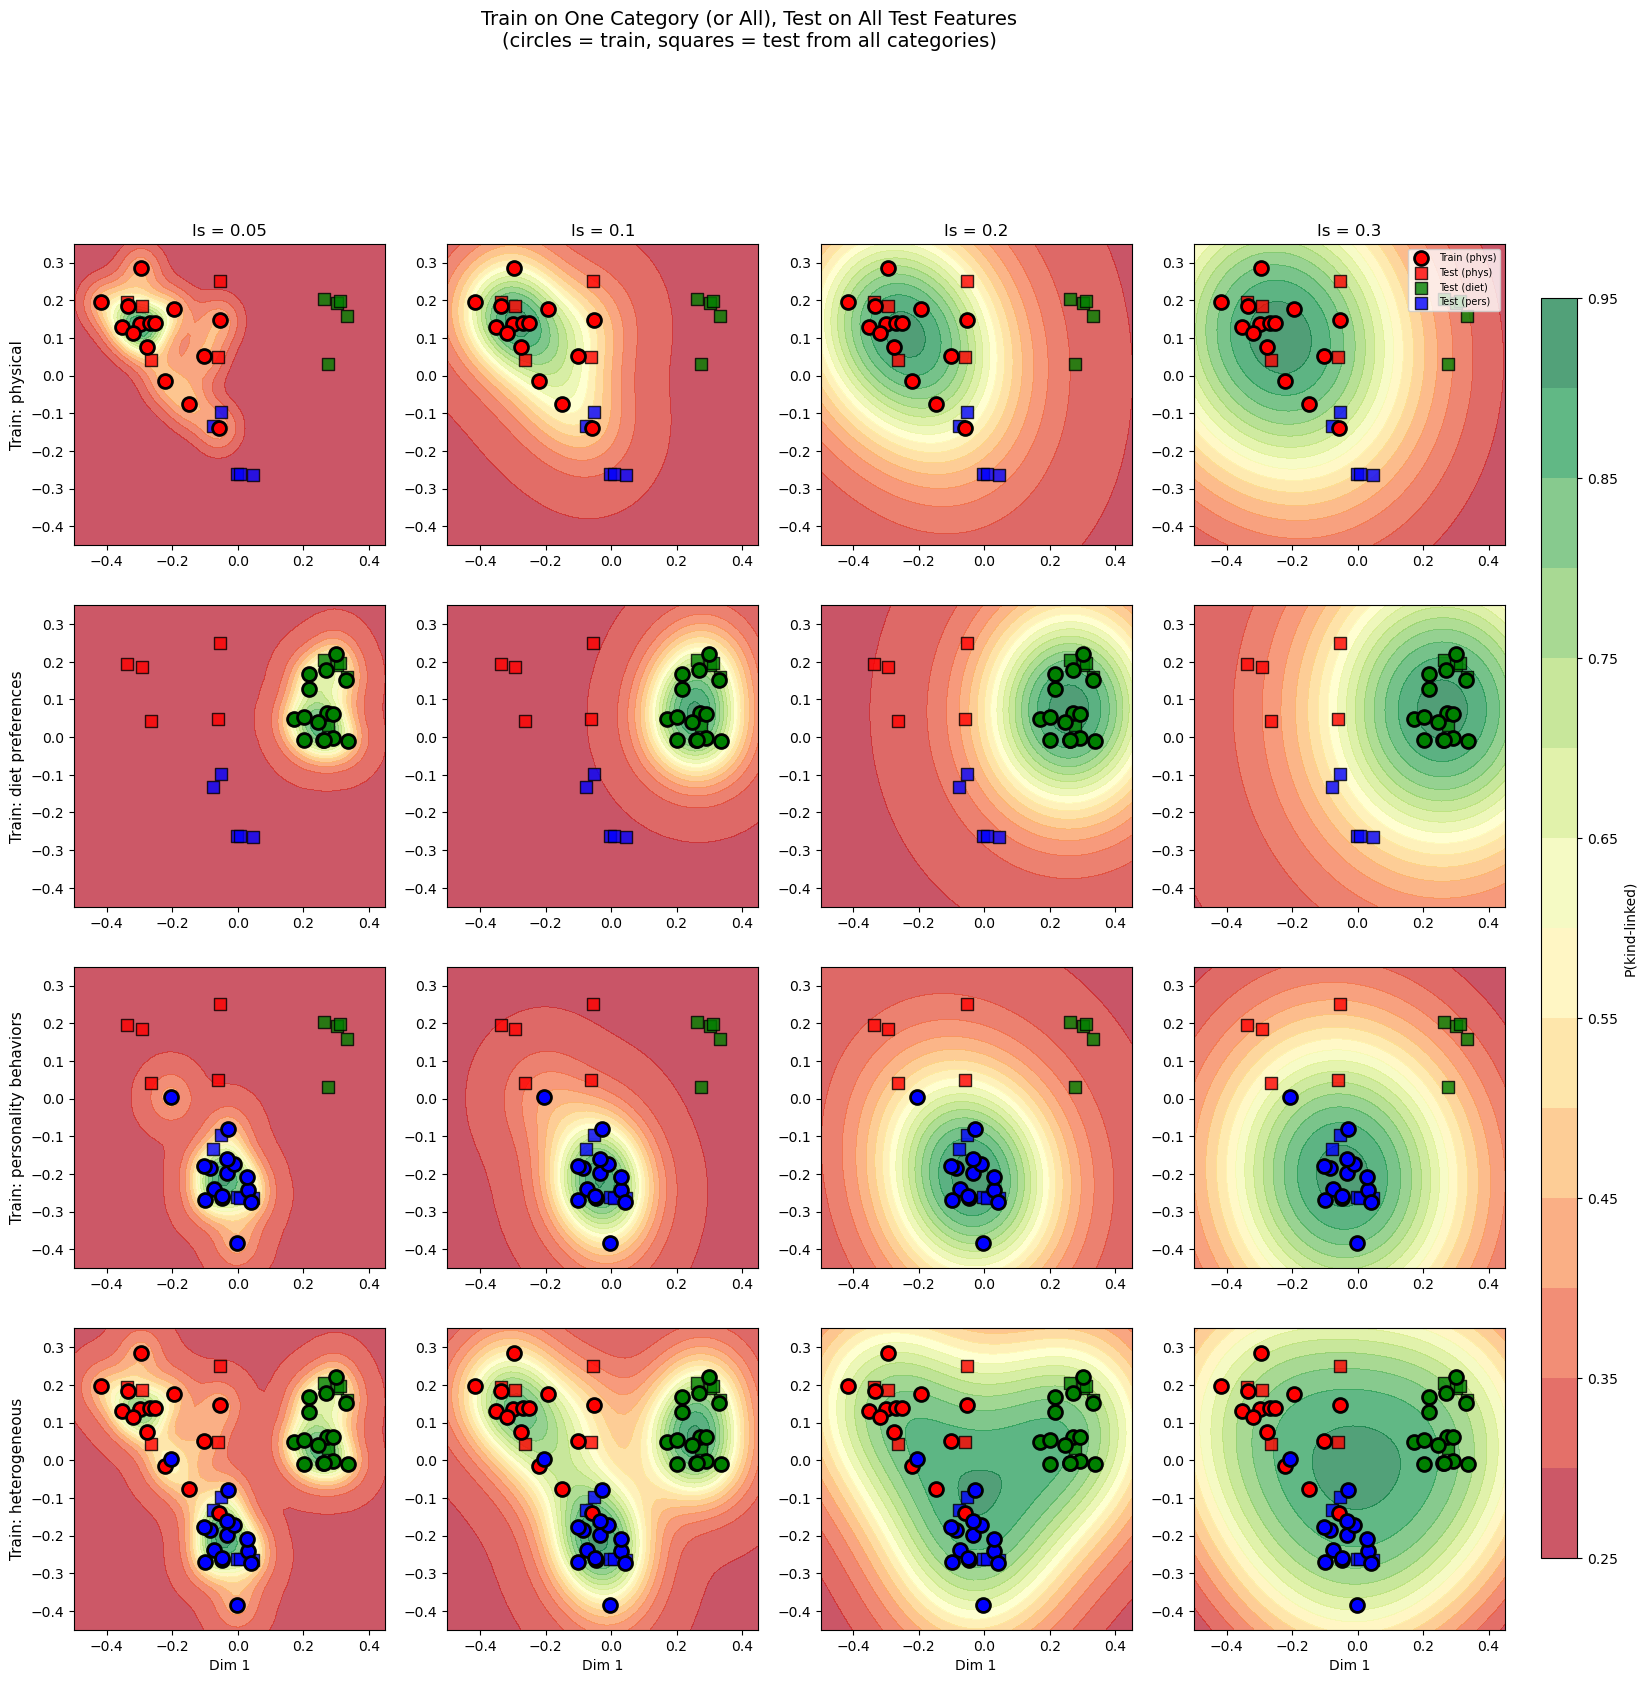

In [19]:
# Compare training on each category separately, with different lengthscales
# Train on split=='train' for one category, test on ALL split=='test' features

training_categories = [
    ('physical', 'red'),
    ('diet_preferences', 'green'),
    ('personality_behaviors', 'blue'),
    ('heterogeneous', 'purple'),  # All categories combined
]

lengthscales = [0.05, 0.10, 0.20, 0.30]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

# Color markers by category
cat_colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}

# Grid setup
x_min, x_max = -0.5, 0.45
y_min, y_max = -0.45, 0.35
xx, yy = jnp.meshgrid(
    jnp.linspace(x_min, x_max, 50),
    jnp.linspace(y_min, y_max, 50)
)
grid_coords = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

# Get ALL test features (from all categories)
all_test_df = df[df['split'] == 'test']

for row, (train_cat, train_color) in enumerate(training_categories):
    # Get TRAINING data
    if train_cat == 'heterogeneous':
        # Train on ALL training data from all categories
        cat_train_df = df[df['split'] == 'train']
    else:
        # Train on this category only (split == 'train')
        cat_train_df = df[(df['category'] == train_cat) & (df['split'] == 'train')]
    
    cat_train_coords = jnp.array(cat_train_df[['x_2d', 'y_2d']].values)
    cat_train_labels = jnp.ones(len(cat_train_coords))
    
    for col, ls in enumerate(lengthscales):
        ax = axes[row, col]
        manual_params = jnp.array([1.0, ls, ls])
        
        # Predict on grid
        probs_grid, _, _ = gp.laplace_predict(
            X_train=cat_train_coords,
            y_train=cat_train_labels,
            X_test=grid_coords,
            kernel_params=manual_params,
            kernel_name="rbf_2d_ard",
            prior_mean=-2.0
        )
        probs_grid = probs_grid.reshape(xx.shape)
        
        # Plot heatmap
        im = ax.contourf(xx, yy, probs_grid, levels=15, cmap='RdYlGn', alpha=0.7)
        
        # Plot training points (circles with black edge)
        if train_cat == 'heterogeneous':
            # For heterogeneous, color training points by their actual category
            for train_cat_name, train_cat_color in cat_colors.items():
                train_cat_subset = cat_train_df[cat_train_df['category'] == train_cat_name]
                ax.scatter(train_cat_subset['x_2d'], train_cat_subset['y_2d'], 
                           c=train_cat_color, s=100, marker='o',
                           edgecolors='black', linewidths=2,
                           label=f'Train ({train_cat_name[:4]})', zorder=5)
        else:
            ax.scatter(cat_train_coords[:, 0], cat_train_coords[:, 1], 
                       c=train_color, s=100, marker='o',
                       edgecolors='black', linewidths=2,
                       label=f'Train ({train_cat[:4]})', zorder=5)
        
        # Plot ALL test points, colored by their category
        for test_cat, test_color in cat_colors.items():
            test_cat_df = all_test_df[all_test_df['category'] == test_cat]
            ax.scatter(test_cat_df['x_2d'], test_cat_df['y_2d'], 
                       c=test_color, s=80, marker='s', alpha=0.8,
                       edgecolors='black', linewidths=1,
                       label=f'Test ({test_cat[:4]})', zorder=4)
        
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        # Labels
        if row == 0:
            ax.set_title(f'ls = {ls}', fontsize=12)
        if col == 0:
            ax.set_ylabel(f'Train: {train_cat.replace("_", " ")}', fontsize=11)
        if row == 3:
            ax.set_xlabel('Dim 1', fontsize=10)
        if row == 0 and col == 3:
            ax.legend(loc='upper right', fontsize=7)

# Add single colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='P(kind-linked)')

plt.suptitle('Train on One Category (or All), Test on All Test Features\n(circles = train, squares = test from all categories)', 
             fontsize=14, y=1.01)
# plt.tight_layout(rect=[0, 0, 0.92, 0.98])
plt.show()

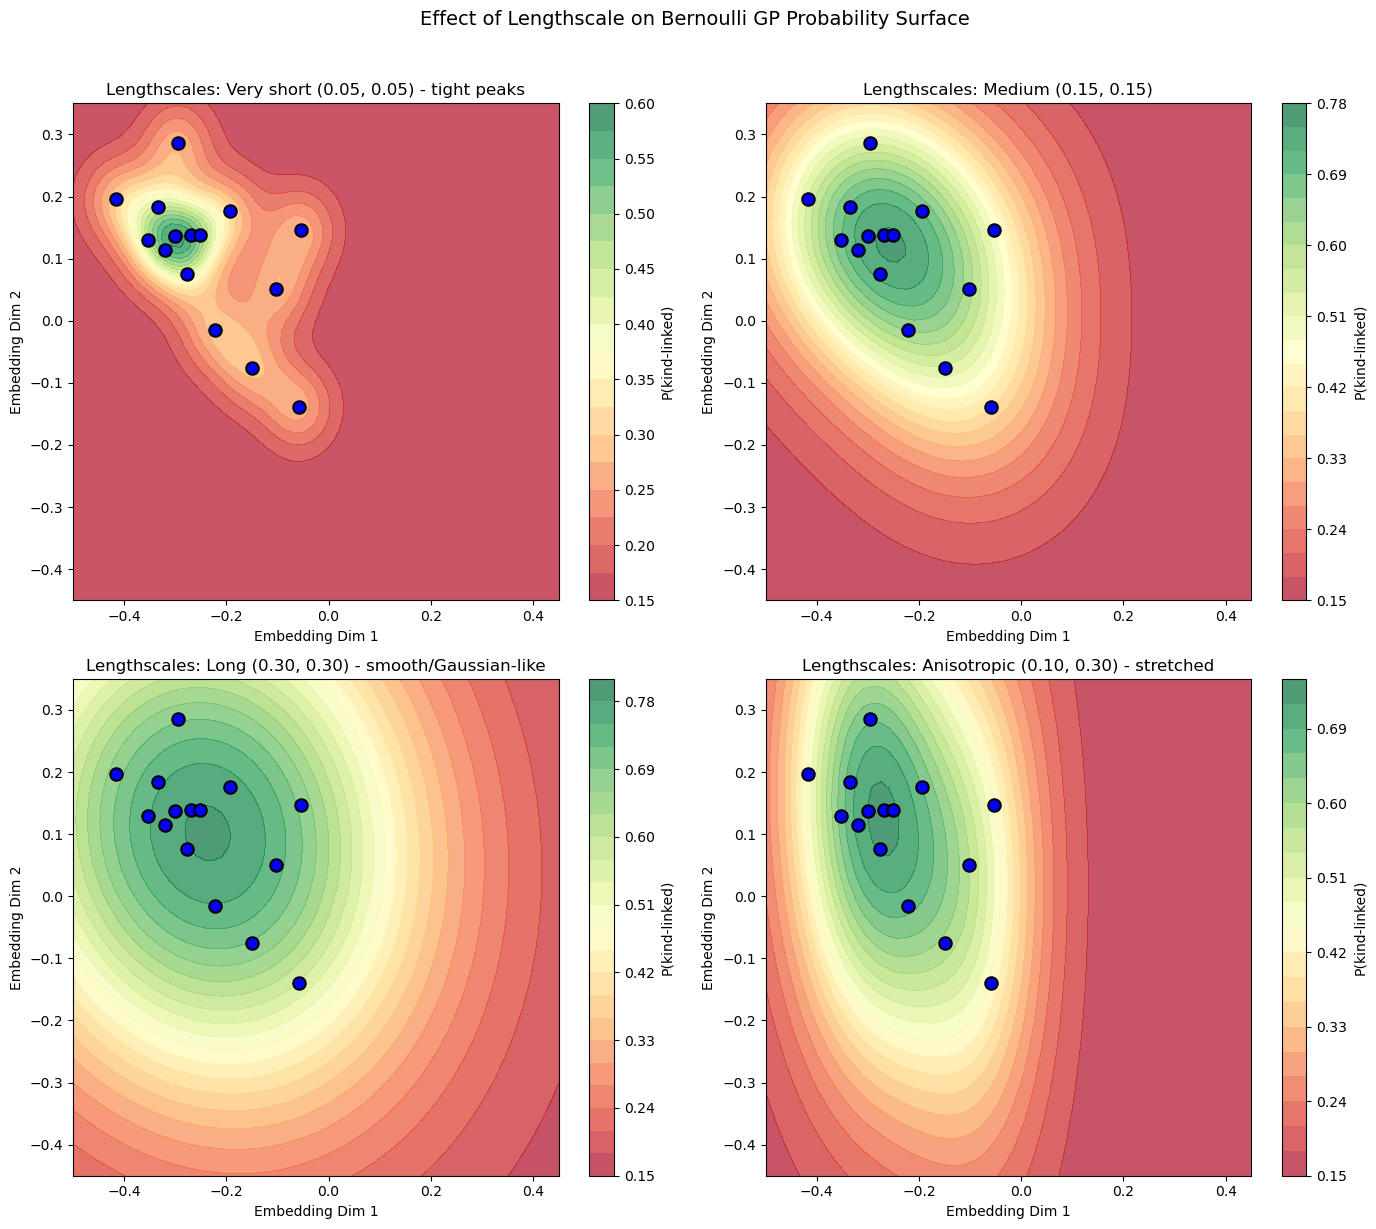

In [20]:
# Compare different lengthscales to see how they affect the probability surface
# Using the physical training data

lengthscale_settings = [
    (0.05, 0.05, "Very short (0.05, 0.05) - tight peaks"),
    (0.15, 0.15, "Medium (0.15, 0.15)"),
    (0.30, 0.30, "Long (0.30, 0.30) - smooth/Gaussian-like"),
    (0.10, 0.30, "Anisotropic (0.10, 0.30) - stretched"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (lx, ly, title) in zip(axes, lengthscale_settings):
    # Fixed hyperparameters: sigma=1.0, lengthscale_x, lengthscale_y
    manual_params = jnp.array([1.0, lx, ly])
    
    # Create grid for heatmap
    x_min, x_max = -0.5, 0.45
    y_min, y_max = -0.45, 0.35
    xx, yy = jnp.meshgrid(
        jnp.linspace(x_min, x_max, 60),
        jnp.linspace(y_min, y_max, 60)
    )
    grid_coords = jnp.stack([xx.ravel(), yy.ravel()], axis=1)
    
    # Predict on grid
    probs_grid, _, _ = gp.laplace_predict(
        X_train=train_coords,
        y_train=train_labels,
        X_test=grid_coords,
        kernel_params=manual_params,
        kernel_name="rbf_2d_ard",
        prior_mean=-2.0
    )
    probs_grid = probs_grid.reshape(xx.shape)
    
    # Plot
    im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='RdYlGn', alpha=0.7)
    plt.colorbar(im, ax=ax, label='P(kind-linked)')
    
    # Training points
    ax.scatter(train_coords[:, 0], train_coords[:, 1], 
               c='blue', s=80, edgecolors='black', linewidths=1.5, 
               label='Training', zorder=5)
    
    ax.set_xlabel('Embedding Dim 1')
    ax.set_ylabel('Embedding Dim 2')
    ax.set_title(f'Lengthscales: {title}')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.suptitle('Effect of Lengthscale on Bernoulli GP Probability Surface', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()